EDA of Titanic

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
PATH = "../data/raw/train.csv"


In [3]:
def load_dataset(path:str) -> pd.DataFrame :
    df :pd.DataFrame = pd.read_csv(path)
    return df

df = load_dataset(PATH)


In [4]:
def inspect_dataset(df : pd.DataFrame ) -> None :
    print("Dataset shape =",df.shape)
    print("Coloumns in dataset",df.columns.tolist)
    print("First five row:\n",df.head())
    print("Data type of dataset:\n ",df.dtypes)
    print(" Summary Statestics =\n",df.describe(include="all"))
    df.info()
    
inspect_dataset(df)


Dataset shape = (891, 12)
Coloumns in dataset <bound method IndexOpsMixin.tolist of Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')>
First five row:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0       

In [5]:

def Missing_Summary(df : pd.DataFrame) -> pd.DataFrame :
    missing = []
    missing_value = [] 
    missing_percentage = []
    for cols in  df.columns.tolist():
        if df[cols].isnull().sum() != 0 :
            value = int((df[cols].isnull().sum()))
            total = int(df.shape[0])
            percentage = (value /total)*100
            missing.append(cols)
            missing_value.append(value)
            missing_percentage.append(percentage)
    missing_columns = pd.DataFrame(list(zip(missing_value,missing_percentage)) , index = missing  , columns = ["Missing_Count","Missing_Percentage"]).sort_values("Missing_Percentage",ascending=False)
    return missing_columns


Summary_of_Missing = Missing_Summary(df)
print(Summary_of_Missing)


          Missing_Count  Missing_Percentage
Cabin               687           77.104377
Age                 177           19.865320
Embarked              2            0.224467


In [6]:
def check_duplicates(df : pd.DataFrame) -> None:
    duplicate_row = df.duplicated().sum()
    return duplicate_row
print( "duplicated rows =",check_duplicates(df)  )


duplicated rows = 0


In [7]:
feature_assessment = pd.DataFrame({
    "Role": ["Identifier","Target","Feature","Feature","Feature","Feature","Feature","Feature","Feature","Feature","Feature","Feature"],
    "Semantic_Type": ["ID","Binary categorical","Ordinal categorical","High-cardinality text","Binary categorical","Continuous numerical","Discrete numerical","Discrete numerical","High-cardinality categorical","Continuous numerical","High-cardinality text","Nominal categorical"],
    "Decision": ["Drop","Keep","Keep","Transform","Keep","Keep","Keep / Transform","Keep / Transform","Drop initially","Keep","Transform","Keep"],
},index =list(df.columns.to_list()),)
print(feature_assessment)
categorical_feature = ["Sex", "Embarked","Pclass"]
#passenger is dropped it doesn't signifance anything.
#survived is traget variable
#class is  feature , that will determine with hireachy as of vaule
#Sex is binary categorical feature , help me  which determining which gender is saved the most or not
#Name , binary categorical  ,is feature must be like transformed to understand married and non married status
#Age is feature which detremine , a numerical data
#Embarked is from location C: Cherbourg (France),Q: Queenstown (now Cobh, Ireland),S: Southampton (England), will consider as feature , and categorical
#ticket i can't determine much so i will drop 
#CAbin  is also can't determine any bine anything much
# fare is numerical feature , it will help  to determine cost 
#Sib/Suppose is nnumerical feature , family , and non family who survive the most 
#Parch (pareent/child)  is numerical 



                   Role                 Semantic_Type          Decision
PassengerId  Identifier                            ID              Drop
Survived         Target            Binary categorical              Keep
Pclass          Feature           Ordinal categorical              Keep
Name            Feature         High-cardinality text         Transform
Sex             Feature            Binary categorical              Keep
Age             Feature          Continuous numerical              Keep
SibSp           Feature            Discrete numerical  Keep / Transform
Parch           Feature            Discrete numerical  Keep / Transform
Ticket          Feature  High-cardinality categorical    Drop initially
Fare            Feature          Continuous numerical              Keep
Cabin           Feature         High-cardinality text         Transform
Embarked        Feature           Nominal categorical              Keep


In [8]:
column_groups = {
    "continuous_numerical": ["Age", "Fare"],
    "discrete_numerical": ["SibSp", "Parch"],
    "binary_categorical": ["Sex"],
    "nominal_categorical": ["Embarked"],
    "ordinal_categorical": ["Pclass"],
    "high_cardinality": ["Name", "Cabin", "Ticket"],
    "identifier": ["PassengerId"],
    "target": ["Survived"]
    }
print(column_groups["continuous_numerical"])


['Age', 'Fare']


CONTINUOUS FEATURE : Age
DATA QUALITY
Missing quantity :177
Missing percentage:19.87%
CENTRAL TENDENCY
Mean :29.7


Median :28.0
DISTRIBUTION
Standard Deviation :14.53
Skew :0.39
Histogram:
IQR ANALYSIS
Q1 :20.125
Q3 :38.0
IQR[Q3 -Q1] :17.875
Upper bound[Q3 + 1.5*IQR]:64.81 
Lower bound[Q1 - 1.5*IQR]:-6.69 
Number of potential outlier:11 
percantage of potential outlier:1.23
HISTOGRAM+KDE


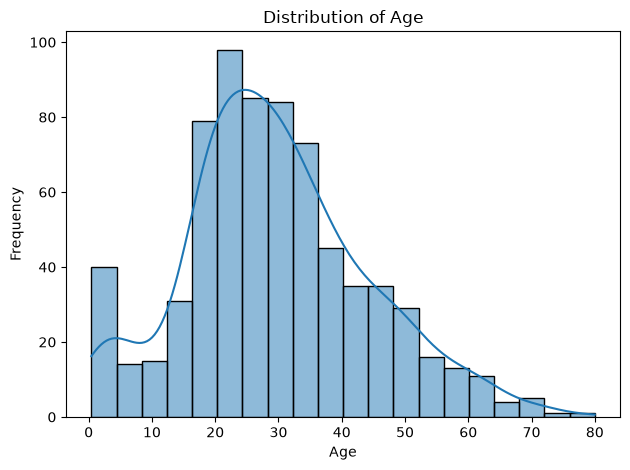

Boxplot:


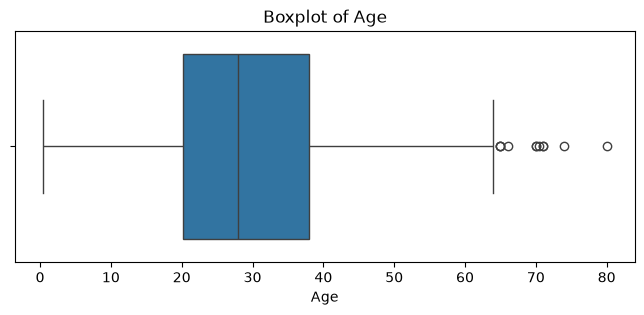

CONTINUOUS FEATURE : Fare
DATA QUALITY
Missing quantity :0
Missing percentage:0.0%
CENTRAL TENDENCY
Mean :32.2
Median :14.45
DISTRIBUTION
Standard Deviation :49.69
Skew :4.79
Histogram:
IQR ANALYSIS
Q1 :7.9104
Q3 :31.0
IQR[Q3 -Q1] :23.0896
Upper bound[Q3 + 1.5*IQR]:65.63 
Lower bound[Q1 - 1.5*IQR]:-26.72 
Number of potential outlier:116 
percantage of potential outlier:13.02
HISTOGRAM+KDE


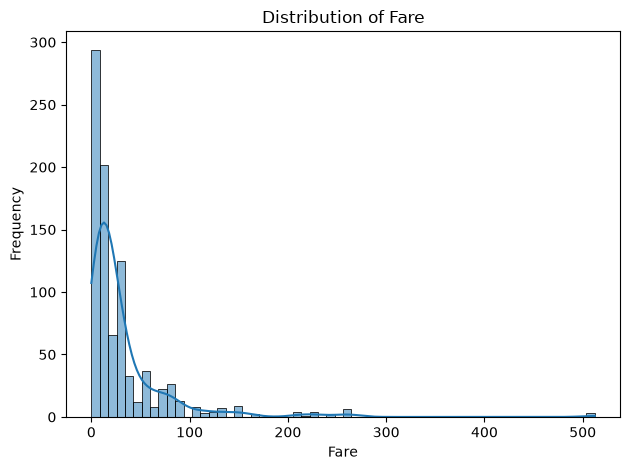

Boxplot:


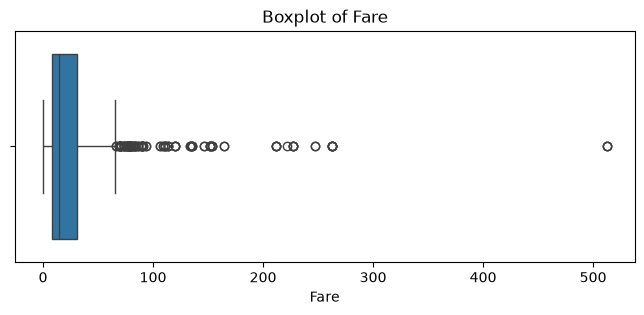

Raw Fare skew:4.79
Log Fare skew:0.39
Histogram for log Fare:


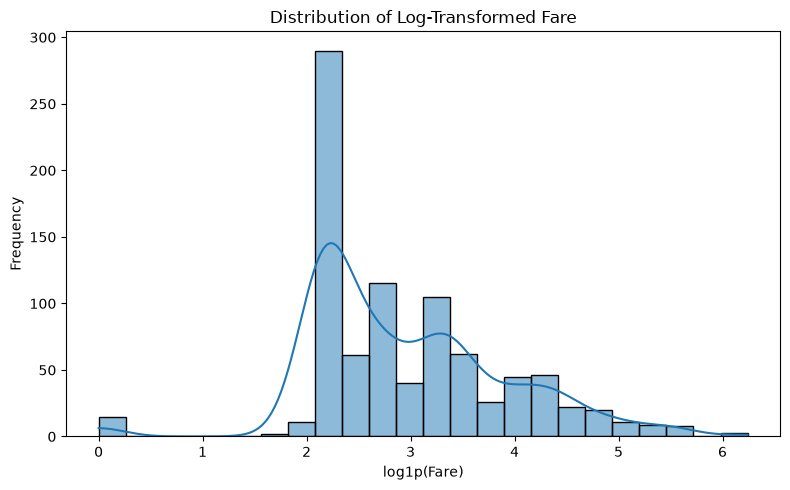

Boxplot for log Fare


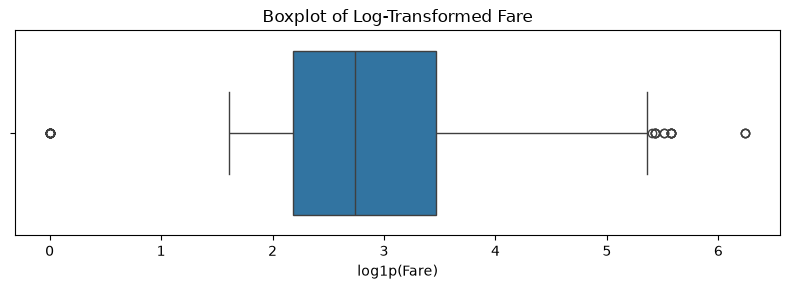

In [9]:
def analyze_continous(df : pd.DataFrame, columns: list[str]):
    for col in columns:

        print(f"CONTINUOUS FEATURE : {col}")
        
        print("DATA QUALITY")
        print(f"Missing quantity :{df[col].isnull().sum()}")
        print(f"Missing percentage:{round((df[col].isnull().sum()/df[col].shape[0]*100),2)}%")

        print("CENTRAL TENDENCY")
        print(f"Mean :{round(float(df[col].mean()),2)}")
        print(f"Median :{round(float(df[col].median()),2)}")

        print("DISTRIBUTION")
        print(f"Standard Deviation :{round(float(df[col].std()),2)}")
        print(f"Skew :{round(float(df[col].skew()),2)}")
        print("Histogram:")

        print("IQR ANALYSIS")
        
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + (1.5*iqr)
        lower_bound = q1 - (1.5*iqr)
        potential_outliers: pd.DataFrame = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        percentage_of_potenial_outlier = potential_outliers.shape[0]/df[col].shape[0]*100

        print(f"Q1 :{q1}")
        print(f"Q3 :{q3}")
        print(f"IQR[Q3 -Q1] :{iqr}")
        print(f"Upper bound[Q3 + 1.5*IQR]:{upper_bound:.2f} ")     
        print(f"Lower bound[Q1 - 1.5*IQR]:{lower_bound:.2f} ")
        print(f"Number of potential outlier:{potential_outliers.shape[0]} ")  
        print(f"percantage of potential outlier:{percentage_of_potenial_outlier:.2f}")

        print("HISTOGRAM+KDE")
        sns.histplot(data=df, x=col, kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
        print("Boxplot:")
        plt.figure(figsize=(8, 3))
        sns.boxplot(data=df , x = col)
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.show()
analyze_continous(df,column_groups["continuous_numerical"])
fare_log = np.log1p(df["Fare"])
print(f"Raw Fare skew:{df["Fare"].skew():.2f}")
print(f"Log Fare skew:{fare_log.skew():.2f}")
print("Histogram for log Fare:")
plt.figure(figsize=(8, 5))

sns.histplot(fare_log, kde=True)

plt.title("Distribution of Log-Transformed Fare")
plt.xlabel("log1p(Fare)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("Boxplot for log Fare")
plt.figure(figsize=(8, 3))

sns.boxplot(x=fare_log)

plt.title("Boxplot of Log-Transformed Fare")
plt.xlabel("log1p(Fare)")
plt.tight_layout()
plt.show()


CATEGORICAL FUNCTION :Sex
DATA QUALITY
Missing quantity :0
Missing percentage:0.0%
CARDINALITY
Unique quantity ofSex :<StringArray>
['male', 'female']
Length: 2, dtype: str 
No.of quantity of Sex : 2 
DISTRIBUTION
Absolute frequency:Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64
Percentage frequency:Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64
COUNT DISTIRBUTION


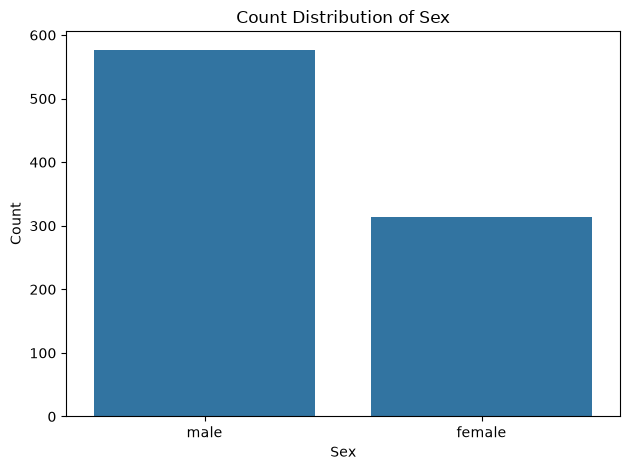

PRECENTAGE DISTRUBTION


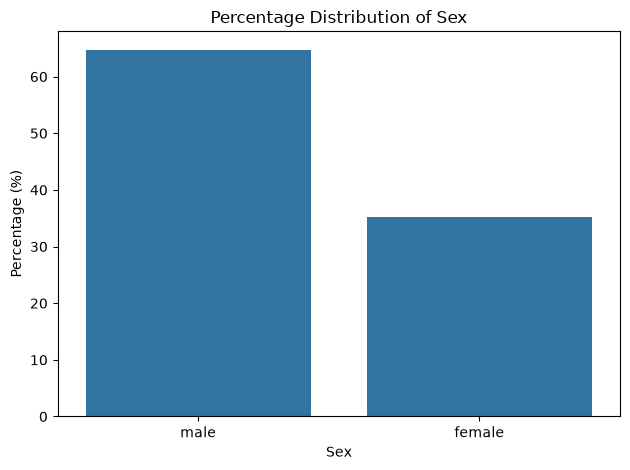

CATEGORICAL FUNCTION :Embarked
DATA QUALITY
Missing quantity :2
Missing percentage:0.22%
CARDINALITY
Unique quantity ofEmbarked :<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str 
No.of quantity of Embarked : 3 
DISTRIBUTION
Absolute frequency:Embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64
Percentage frequency:Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64
COUNT DISTIRBUTION


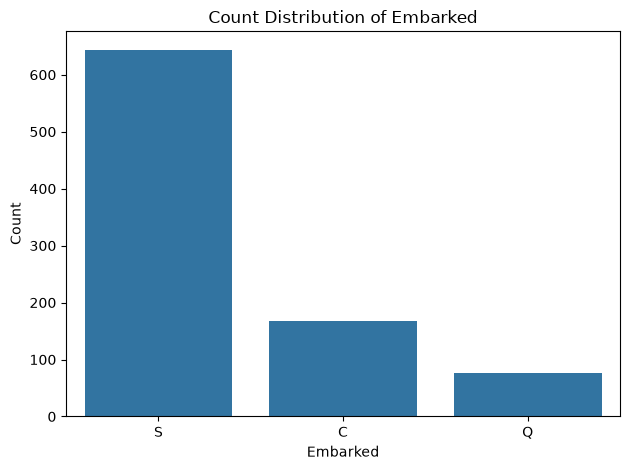

PRECENTAGE DISTRUBTION


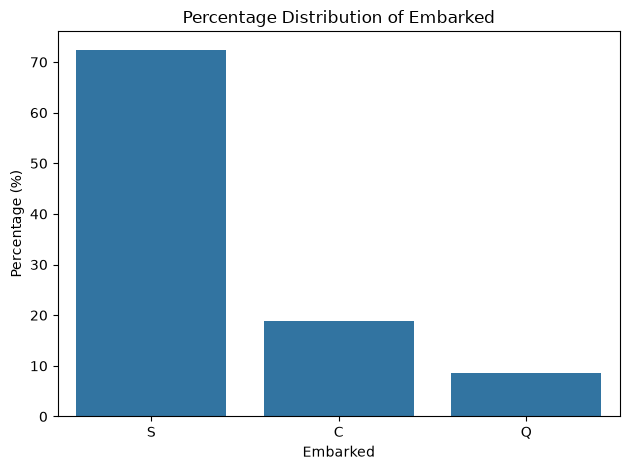

CATEGORICAL FUNCTION :Pclass
DATA QUALITY
Missing quantity :0
Missing percentage:0.0%
CARDINALITY
Unique quantity ofPclass :[3 1 2] 
No.of quantity of Pclass : 3 
DISTRIBUTION
Absolute frequency:Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64
Percentage frequency:Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64
COUNT DISTIRBUTION


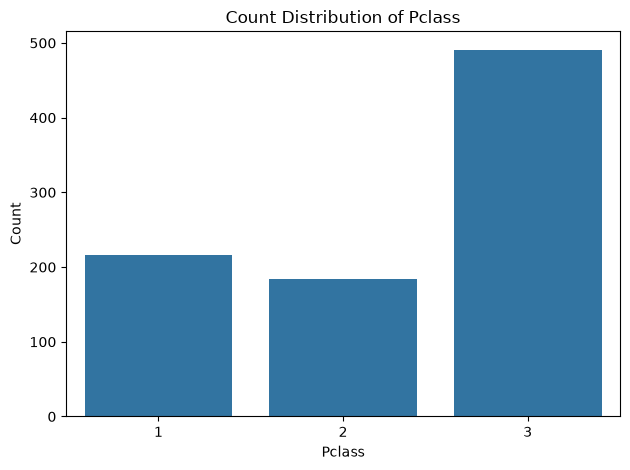

PRECENTAGE DISTRUBTION


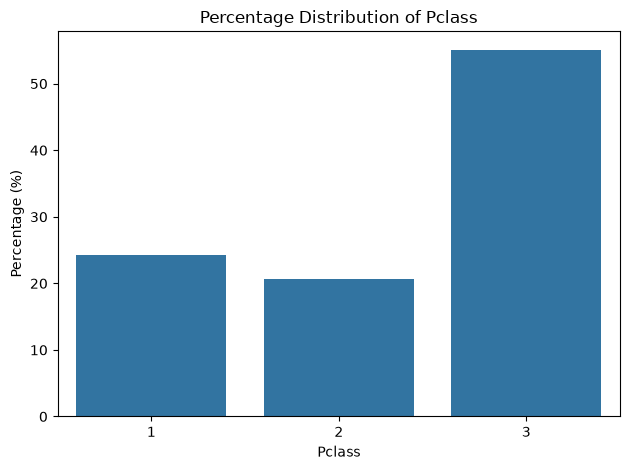

In [19]:
def analyze_categorical(df : pd.DataFrame , columns : list[str]) -> None:
    for col in columns :
        print(f"CATEGORICAL FUNCTION :{col}")

        print("DATA QUALITY")
        print(f"Missing quantity :{df[col].isnull().sum()}")
        print(f"Missing percentage:{round((df[col].isnull().sum()/df[col].shape[0]*100),2)}%")

        print("CARDINALITY")
        print(f"Unique quantity of{col} :{df[col].unique()} ")
        print(f"No.of quantity of {col} : {(df[col].nunique())} ")

        print("DISTRIBUTION")
        print(f"Absolute frequency:{df[col].value_counts( normalize= True)}")
        print(f"Percentage frequency:{df[col].value_counts( normalize=True)*100}")

        print("COUNT DISTIRBUTION")
        sns.countplot(data=df, x=col)
        plt.title(f"Count Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
        print("PRECENTAGE DISTRUBTION") 
        percentage = df[col].value_counts(normalize=True) * 100
        sns.barplot(x=percentage.index, y=percentage.values)

        plt.title(f"Percentage Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Percentage (%)")
        plt.tight_layout()
        plt.show()
analyze_categorical(df,categorical_feature)


DATA QUALITY
Missing quantity : 0
CARDINALITY
unique quantity :[0 1]
0 = Not Survived , 1 = Survived
No. of qunatity for each :
Survived
0    549
1    342
Name: count, dtype: int64
DISTRIBUTION
Average frequency:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
Percentage frequency: 
 Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64
CLASS IMBALANCE
Majority class : 61.62%
Reasonably balanced dataset
COUNT DISTIRBUTION


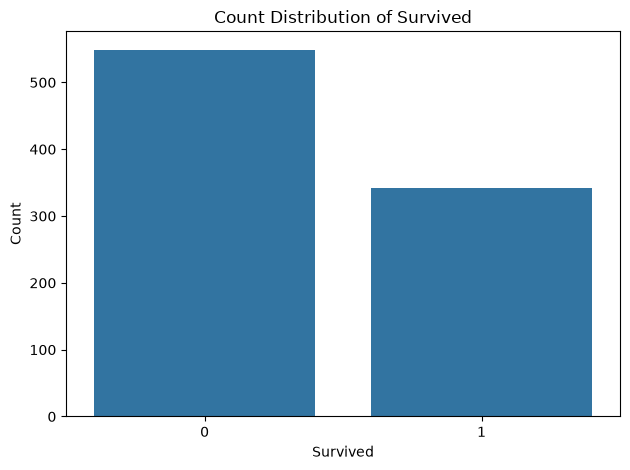

PRECENTAGE DISTRUBTION


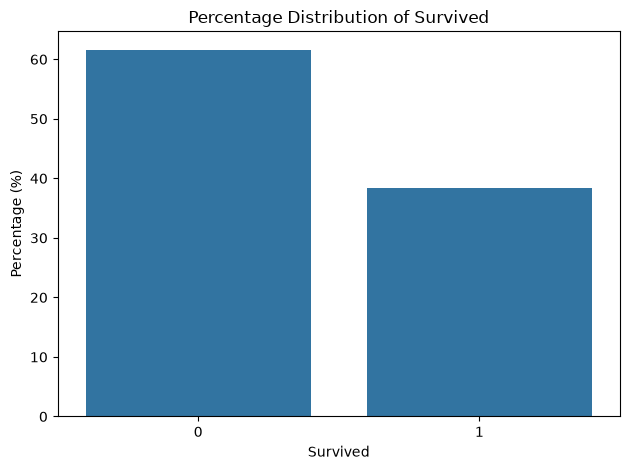

In [ ]:
def Target_analyze(df : pd.DataFrame):
    print("DATA QUALITY")
    print(f"Missing quantity : {df.Survived.isnull().sum()}")
    print(f"CARDINALITY")
    print(f"unique quantity :{df.Survived.unique()}")
    print("0 = Not Survived , 1 = Survived")
    print(f"No. of qunatity for each :\n{df["Survived"].value_counts()}")
    print("DISTRIBUTION")
    print(f"Average frequency:\n{df["Survived"].value_counts(normalize=True)}")
    print(f"Percentage frequency: \n {df["Survived"].value_counts(normalize=True)*100}")
    print("CLASS IMBALANCE")
    major = df["Survived"].value_counts(normalize=True).max()

    print(f"Majority class : {major:.2%}")

    if major > 0.8:
        print("Highly imbalanced dataset")
    elif major > 0.65:
        print("Moderately imbalanced dataset")
    else:
        print("Reasonably balanced dataset")
    print("COUNT DISTIRBUTION")
    sns.countplot(data=df, x="Survived")
    plt.title(f"Count Distribution of {"Survived"}")
    plt.xlabel("Survived")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    print("PRECENTAGE DISTRUBTION") 
    percentage = df["Survived"].value_counts(normalize=True) * 100
    sns.barplot(x=percentage.index, y=percentage.values)

    plt.title(f"Percentage Distribution of {"Survived"}")
    plt.xlabel("Survived")
    plt.ylabel("Percentage (%)")
    plt.tight_layout()
    plt.show()
    
    
Target_analyze(df)
